# 01 — The criterion, on its two paradigm cases: the compact boson (not forced) and Ising (forced)

**Sector Causality Theory** states one criterion: *a self-dual point is forced to be physically
distinguished if and only if it exchanges two inequivalent sectors on a discrete fixed-point set.*
On a continuous family of equivalent theories, the self-dual point is a point like any other, and
any transition sits where one sector crosses its own threshold.

This notebook puts the two paradigm cases side by side, computing everything live:

1. **The compact boson (T-duality)** — the paradigm *not forced* case. Its states are labelled by
   integer **sectors** $(n, w)$: momentum $n$ and winding $w$. T-duality $R \mapsto 2/R$ exchanges
   them. We check numerically that this is a *reindexing of sectors* — the sector sum is invariant —
   and that the self-dual radius $R=\sqrt2$ is **not** where the Berezinskii–Kosterlitz–Thouless
   (BKT) transition happens ($R = 2\sqrt2$).
2. **The 2D Ising model (Kramers–Wannier)** — the paradigm *forced* case: the self-dual coupling is
   exactly the critical point.

Every formula below is the one proved in Lean 4 in [`lean/CompactBoson.lean`](../lean/CompactBoson.lean);
the theorem names are cited next to each check. Nothing here is new physics; the point is to *see*
the distinction the theory draws.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sct_style as S
S.apply()

## 1. Sectors and scaling dimensions

The Lean definitions (`CompactBoson.dim`, `CompactBoson.spin`), at radius $R$:

$$\Delta(n,w;R) = \frac{n^2}{R^2} + \frac{w^2 R^2}{4}, \qquad s(n,w) = n\,w .$$

**T-duality on sectors** (`dim_dual`): $\Delta(n,w;R) = \Delta(w,n;2/R)$ — exchanging momentum and
winding while sending $R\mapsto 2/R$ preserves every dimension. We check it on random sectors.

In [2]:
def dim(R, n, w):
    return n**2 / R**2 + w**2 * R**2 / 4

def spin(n, w):
    return n * w

rng = np.random.default_rng(0)
n, w = rng.integers(-20, 21, size=(2, 10_000))
R = rng.uniform(0.2, 6.0, size=10_000)
err = np.max(np.abs(dim(R, n, w) - dim(2 / R, w, n)))
print(f"max |Δ(n,w;R) − Δ(w,n;2/R)| over 10,000 random (n,w,R): {err:.2e}   (dim_dual)")

max |Δ(n,w;R) − Δ(w,n;2/R)| over 10,000 random (n,w,R): 1.82e-12   (dim_dual)


## 2. The sector sum is duality-invariant — because duality is a reindexing

`partition_dual` proves that for **any** weight $F(\Delta, s)$,
$\sum_{(n,w)\in\mathbb Z^2} F(\Delta(n,w;R), s(n,w)) = \sum_{(n,w)} F(\Delta(n,w;2/R), s(n,w))$,
with no convergence hypothesis: the proof is just "swap $n$ and $w$". We check it with the physical
weight, the lattice part of the torus partition function at modular parameter $\tau=\tau_1+i\tau_2$:
$F = e^{-2\pi\tau_2\Delta}\cos(2\pi\tau_1 s)$, truncated at $|n|,|w|\le 40$ (the weights decay like
$e^{-\Delta}$, so the truncation error is far below double precision).

In [3]:
def Z_lattice(R, tau1=0.3, tau2=1.0, N=40):
    k = np.arange(-N, N + 1)
    nn, ww = np.meshgrid(k, k, indexing="ij")
    return np.sum(np.exp(-2 * np.pi * tau2 * dim(R, nn, ww)) * np.cos(2 * np.pi * tau1 * spin(nn, ww)))

print(f"{'R':>8} {'Z(R)':>14} {'Z(2/R)':>14} {'rel. diff':>11}")
for Rv in (0.5, 0.8, 1.0, np.sqrt(2), 2.0, 2 * np.sqrt(2), 3.5):
    a, b = Z_lattice(Rv), Z_lattice(2 / Rv)
    print(f"{Rv:8.4f} {a:14.8f} {b:14.8f} {abs(a - b) / abs(a):11.1e}")

       R           Z(R)         Z(2/R)   rel. diff
  0.5000     2.82842712     2.82842712     0.0e+00
  0.8000     1.76804080     1.76804080     0.0e+00
  1.0000     1.42273925     1.42273925     1.6e-16
  1.4142     1.17056036     1.17056036     0.0e+00
  2.0000     1.42273925     1.42273925     1.6e-16
  2.8284     2.00001848     2.00001848     0.0e+00
  3.5000     2.47487376     2.47487376     1.8e-16


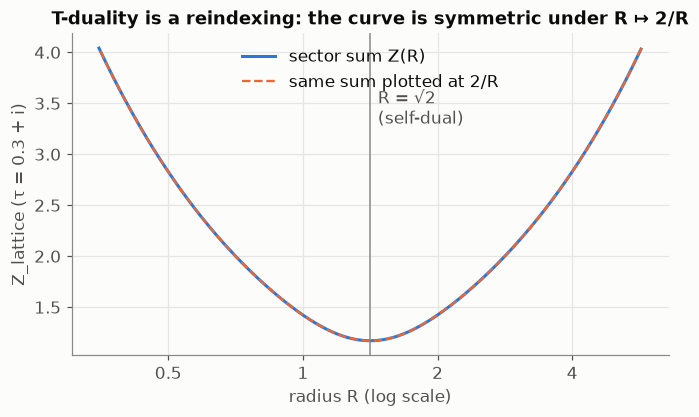

In [4]:
Rs = np.geomspace(0.35, 5.7, 400)
Z = np.array([Z_lattice(r) for r in Rs])
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(Rs, Z, color=S.BLUE, label="sector sum Z(R)")
ax.plot(2 / Rs, Z, color=S.ORANGE, ls="--", lw=1.5, label="same sum plotted at 2/R")
ax.axvline(np.sqrt(2), color=S.MUTED, lw=1)
ax.text(np.sqrt(2) * 1.04, 3.3, "R = √2\n(self-dual)", color=S.INK_2)
ax.set_xscale("log"); S.plain_log_ticks(ax.xaxis, [0.5, 1, 2, 4])
ax.set_xlabel("radius R (log scale)"); ax.set_ylabel("Z_lattice (τ = 0.3 + i)")
ax.set_title("T-duality is a reindexing: the curve is symmetric under R ↦ 2/R")
ax.legend(loc="upper center")
S.save(fig, "01_sector_sum_duality"); plt.show()

The two curves lie exactly on top of each other: the sector sum is the same whether you label the
states by $(n,w)$ at radius $R$ or by $(w,n)$ at radius $2/R$. **The duality is exact — and it is
only a relabelling of sectors.**

## 3. Where is the transition? Not at the self-dual point.

The electric (spin-wave) and magnetic (vortex) dimensions are $\Delta_e=\Delta(1,0)=1/R^2$ and
$\Delta_m=\Delta(0,1)=R^2/4$ (`dim_electric`, `dim_magnetic`). Three Lean theorems:

- `electric_mul_magnetic`: $\Delta_e\,\Delta_m = 1/4$ for **every** $R$ — in the superfluid dictionary
  ($\Delta_e=\eta/2$, $\Delta_m = n_s\lambda_T^2/2$) this is $\eta\, n_s\lambda_T^2 = 1$, the relation the
  parent programme measured to 12–27% on eleven energies in two box sizes;
- `selfDual_radius`, `selfDual_value`: $\Delta_e=\Delta_m$ iff $R=\sqrt2$, where both equal $1/2$;
- `vortex_marginal_radius`: $\Delta_m = 2$ (the vortex operator becomes marginal — the BKT
  condition, Nelson–Kosterlitz) iff $R = 2\sqrt2$; and `bkt_not_selfDual`: $2\sqrt2\neq\sqrt2$.

max |Δe·Δm − 1/4| on the grid: 2.8e-17   (electric_mul_magnetic)
at R=√2 : Δe = 0.500000, Δm = 0.500000   (selfDual_value)
at R=2√2: Δm = 2.000000, η = 2Δe = 0.250000   (vortex_marginal_radius; η = 1/4 at BKT)


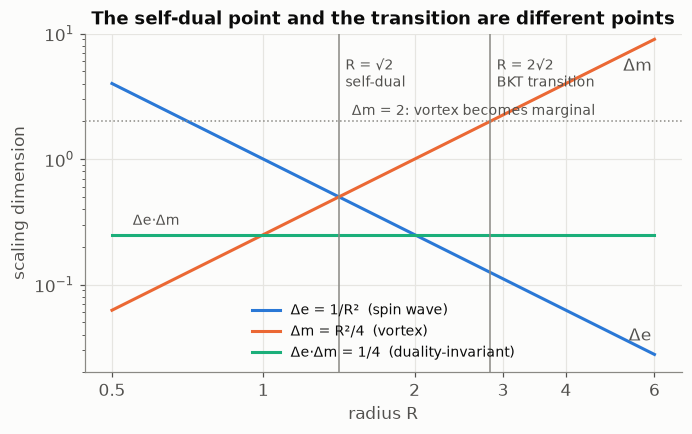

In [5]:
Rs = np.geomspace(0.5, 6, 300)
De, Dm = 1 / Rs**2, Rs**2 / 4
R_sd, R_bkt = np.sqrt(2), 2 * np.sqrt(2)
print(f"max |Δe·Δm − 1/4| on the grid: {np.max(np.abs(De * Dm - 0.25)):.1e}   (electric_mul_magnetic)")
print(f"at R=√2 : Δe = {1/R_sd**2:.6f}, Δm = {R_sd**2/4:.6f}   (selfDual_value)")
print(f"at R=2√2: Δm = {R_bkt**2/4:.6f}, η = 2Δe = {2/R_bkt**2:.6f}   (vortex_marginal_radius; η = 1/4 at BKT)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(Rs, De, color=S.BLUE, label="Δe = 1/R²  (spin wave)")
ax.plot(Rs, Dm, color=S.ORANGE, label="Δm = R²/4  (vortex)")
ax.plot(Rs, De * Dm, color=S.AQUA, label="Δe·Δm = 1/4  (duality-invariant)")
ax.axhline(2, color=S.MUTED, lw=1, ls=":")
ax.text(1.5, 2.25, "Δm = 2: vortex becomes marginal", color=S.INK_2, fontsize=9)
for x, lab in ((R_sd, "R = √2\nself-dual"), (R_bkt, "R = 2√2\nBKT transition")):
    ax.axvline(x, color=S.MUTED, lw=1)
    ax.text(x * 1.03, 6.5, lab, color=S.INK_2, fontsize=9, va="top")
ax.text(5.9, 1 / 5.9**2 * 1.25, "Δe", color=S.INK_2, ha="right"); ax.text(5.2, 5.2**2 / 4 * 0.75, "Δm", color=S.INK_2)
ax.text(0.55, 0.3, "Δe·Δm", color=S.INK_2, fontsize=9)
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_ylim(0.02, 10)
S.plain_log_ticks(ax.xaxis, [0.5, 1, 2, 3, 4, 6])
ax.set_xlabel("radius R"); ax.set_ylabel("scaling dimension")
ax.set_title("The self-dual point and the transition are different points")
ax.legend(loc="lower center", fontsize=9)
S.save(fig, "01_dimensions_vs_radius"); plt.show()

The self-dual radius $\sqrt2$ is where the two sectors' dimensions cross — and **nothing happens
there**. The transition sits at $2\sqrt2$, where *one* sector (vortices) crosses *its own* threshold.
Along the whole line of radii the theory is a single family of equivalent conformal field theories;
the self-dual point is an enhanced-symmetry point on a continuum. **Verdict: not forced.**

## 4. Contrast: Ising, where the self-dual point *is* the transition

The square-lattice Ising model has Kramers–Wannier duality between coupling $K$ and
$K^\star = -\tfrac12\ln\tanh K$. It exchanges the ordered and disordered **sectors**, which are
inequivalent and gapped, and $\mathbb Z_2$ has exactly one symmetric point: $\sinh 2K_c = 1$,
$K_c=\tfrac12\ln(1+\sqrt2)$. Onsager and Yang's exact spontaneous magnetisation,
$M = (1-\sinh^{-4}2K)^{1/8}$ for $K>K_c$ and $0$ otherwise, shows the transition sits **exactly** at the
self-dual point. (Ising is cited, not formalised, in this repository: the checkable content is an
elementary fixed point.)

K_c = 0.4406867935;  sinh(2K_c) = 1.000000000000;  K*(K_c) − K_c = 1.1e-16


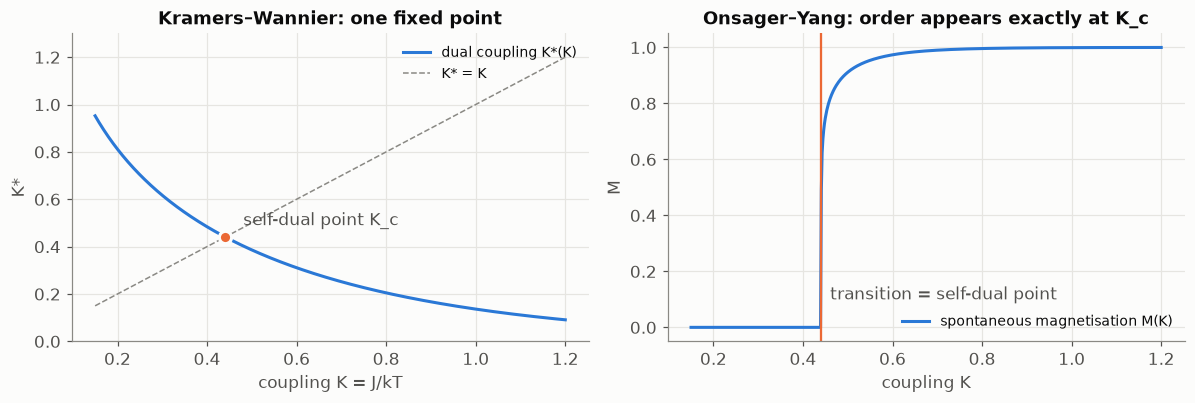

In [6]:
K_c = 0.5 * np.log(1 + np.sqrt(2))
Kstar = lambda K: -0.5 * np.log(np.tanh(K))
print(f"K_c = {K_c:.10f};  sinh(2K_c) = {np.sinh(2*K_c):.12f};  K*(K_c) − K_c = {Kstar(K_c) - K_c:.1e}")

K = np.linspace(0.15, 1.2, 600)
M = np.where(K > K_c, np.clip(1 - np.sinh(2 * K) ** -4, 0, None) ** 0.125, 0.0)
fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
ax = axs[0]
ax.plot(K, Kstar(K), color=S.BLUE, label="dual coupling K*(K)")
ax.plot(K, K, color=S.MUTED, lw=1, ls="--", label="K* = K")
ax.plot([K_c], [K_c], "o", color=S.ORANGE, ms=8, mec=S.SURFACE, mew=2)
ax.text(K_c + 0.04, K_c + 0.05, "self-dual point K_c", color=S.INK_2)
ax.set_xlabel("coupling K = J/kT"); ax.set_ylabel("K*"); ax.set_ylim(0, 1.3)
ax.set_title("Kramers–Wannier: one fixed point"); ax.legend(fontsize=9, loc="upper right")
ax = axs[1]
ax.plot(K, M, color=S.BLUE, label="spontaneous magnetisation M(K)")
ax.axvline(K_c, color=S.ORANGE, lw=1.5)
ax.text(K_c + 0.02, 0.1, "transition = self-dual point", color=S.INK_2)
ax.set_xlabel("coupling K"); ax.set_ylabel("M"); ax.set_title("Onsager–Yang: order appears exactly at K_c")
ax.legend(fontsize=9, loc="lower right")
fig.tight_layout(); S.save(fig, "01_ising_forced"); plt.show()

## Summary

| case | sectors | duality | fixed-point set | where the transition is | verdict |
|---|---|---|---|---|---|
| compact boson | $(n,w)\in\mathbb Z^2$ | $R\mapsto 2/R$ | a continuous line of CFTs, self-dual at $\sqrt2$ | $R=2\sqrt2$ (one sector's threshold) | **not forced** |
| 2D Ising | ordered / disordered | $K\mapsto K^\star$ | one discrete point | exactly at $K_c$ | **forced** |

In both cases the duality is exact. What differs is what it is a fixed point *of*. The remaining
fourteen candidate cases are in [`docs/CASE_TABLE.md`](../docs/CASE_TABLE.md) and in the
foundation paper [`papers/sector_thesis.pdf`](../papers/sector_thesis.pdf).